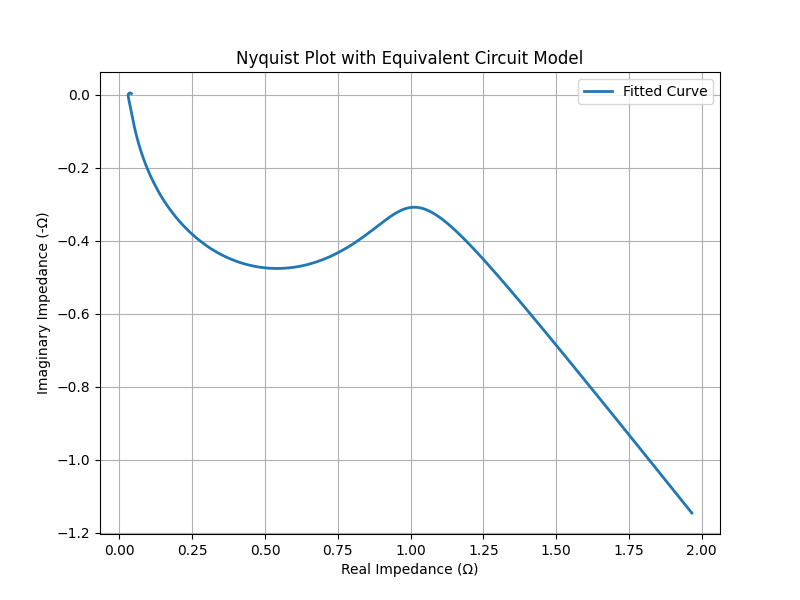

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget 
# 定义等效电路模型
def equivalent_circuit_model(f):
    R1 = 0.0239  # 串联电阻 (Ω)
    R2 = 0.01977  # 并联电阻 (Ω)
    Q = 0.88948  # 恒相位元件参数
    n = 0.62659  # 恒相位元件指数
    L1 = 300e-9  # 并联电感 (H)
    R3 = 0.8  # 并联电阻 (Ω)
    k = 6.444e-5  # 数据2的系数 (Ω * sqrt(Hz))

    omega = 2 * np.pi * f

    # CPE 元件阻抗
    Z_CPE = 1 / (Q * (1j * omega) ** n)

    # CPE 并联 R2 的阻抗
    Z_CPE_R2 = 1 / (1 / Z_CPE + 1 / R2)

    # L1 并联 R3 的阻抗
    Z_L1_R3 = 1 / (1 / (1j * omega * L1) + 1 / R3)

    # Model1 的总阻抗
    Z_model1 = R1 + Z_CPE_R2 + Z_L1_R3

    # 数据2的模型部分
    Z_model2 = k * np.sqrt(1j * omega)

    # 总阻抗
    Z_total = Z_model1 + Z_model2
    return np.real(Z_total), np.imag(Z_total)

# 使用模型计算全频率范围内的阻抗
frequencies = np.logspace(1, 8, 500)  # 频率范围 10kHz - 100MHz
real_part, imag_part = equivalent_circuit_model(frequencies)

# 绘制 Nyquist 图
plt.figure(figsize=(8, 6))
plt.plot(real_part, -imag_part, '-', label='Fitted Curve', linewidth=2)
plt.title('Nyquist Plot with Equivalent Circuit Model')
plt.xlabel('Real Impedance (Ω)')
plt.ylabel('Imaginary Impedance (-Ω)')
plt.grid(True)
plt.legend()
plt.show()


In [10]:
from pathlib import Path

class DisplayablePath(object):
    display_filename_prefix_middle = '├──'
    display_filename_prefix_last = '└──'
    display_parent_prefix_middle = '    '
    display_parent_prefix_last = '│   '

    def __init__(self, path, parent_path, is_last):
        self.path = Path(str(path))
        self.parent = parent_path
        self.is_last = is_last
        if self.parent:
            self.depth = self.parent.depth + 1
        else:
            self.depth = 0

    @property
    def displayname(self):
        if self.path.is_dir():
            return self.path.name + '/'
        return self.path.name

    @classmethod
    def make_tree(cls, root, parent=None, is_last=False, criteria=None):
        root = Path(str(root))
        criteria = criteria or cls._default_criteria

        displayable_root = cls(root, parent, is_last)
        yield displayable_root

        children = sorted(list(path
                               for path in root.iterdir()
                               if criteria(path)),
                          key=lambda s: str(s).lower())
        count = 1
        for path in children:
            is_last = count == len(children)
            if path.is_dir():
                yield from cls.make_tree(path,
                                         parent=displayable_root,
                                         is_last=is_last,
                                         criteria=criteria)
            else:
                yield cls(path, displayable_root, is_last)
            count += 1

    @classmethod
    def _default_criteria(cls, path):
        return True

    @property
    def displayname(self):
        if self.path.is_dir():
            return self.path.name + '/'
        return self.path.name

    def displayable(self):
        if self.parent is None:
            return self.displayname

        _filename_prefix = (self.display_filename_prefix_last
                            if self.is_last
                            else self.display_filename_prefix_middle)

        parts = ['{!s} {!s}'.format(_filename_prefix,
                                    self.displayname)]

        parent = self.parent
        while parent and parent.parent is not None:
            parts.append(self.display_parent_prefix_middle
                         if parent.is_last
                         else self.display_parent_prefix_last)
            parent = parent.parent

        return ''.join(reversed(parts))

In [1]:
import seedir as sd
import emoji
sd.seedir(r"Z:\Forschung\bgA\J7045_Futavis_Modultests\Daten\2_Data_Futavis\Zellen\Zyklische Alterung", style="emoji")

📁 Zyklische Alterung/
├─📄 5D730320.tmp
├─📁 Abschlussprüfung/
│ ├─📁 Extremes Profil/
│ │ ├─📁 dynKap 45C/
│ │ │ ├─📄 CUenderweitert45C_CELL_NR10_.mat
│ │ │ ├─📄 CUenderweitert45C_CELL_NR11_.mat
│ │ │ ├─📄 CUenderweitert45C_CELL_NR12_.mat
│ │ │ ├─📄 CUenderweitert45C_CELL_NR13_.mat
│ │ │ ├─📄 CUenderweitert45C_CELL_NR15_.mat
│ │ │ └─📄 Extremes Profil_dynKap 45C.xlsx
│ │ ├─📁 EX EIS END/
│ │ │ ├─📁 25C/
│ │ │ │ ├─📁 10/
│ │ │ │ │ ├─📄 CELL_NR10_CH00_00001_Inspectr.csv
│ │ │ │ │ ├─📄 CELL_NR11_CH00_00001_Inspectr.csv
│ │ │ │ │ ├─📄 CELL_NR12_CH00_00001_Inspectr.csv
│ │ │ │ │ ├─📄 CELL_NR13_CH00_00001_Inspectr.csv
│ │ │ │ │ ├─📄 CELL_NR15_CH00_00001_Inspectr.csv
│ │ │ │ │ └─📁 sweep/
│ │ │ │ │   ├─📄 CELL_NR10_CH00_00001_InspecSw.csv
│ │ │ │ │   ├─📄 CELL_NR11_CH00_00001_InspecSw.csv
│ │ │ │ │   ├─📄 CELL_NR12_CH00_00001_InspecSw (bad).csv
│ │ │ │ │   ├─📄 CELL_NR13_CH00_00001_InspecSw.csv
│ │ │ │ │   └─📄 CELL_NR15_CH00_00001_InspecSw.csv
│ │ │ │ ├─📁 50/
│ │ │ │ │ └─📁 sweep/
│ │ │ │ │   ├─📄 CELL_NR10_CH00_000